<h1 style="text-align: center;">📘 Baseline_Follow up Indonesia Data Processing and Analysis</h1>

This notebook documents the process of preparing and analyzing data collected from the **GG8 Baseline and Follow-up survey** conducted in **Indonesia**. It was administered in two distinct cohorts: **Year 1** and **Year 2**, with each year including data collected at **baseline** and at **follow-up** of the training interventions. 

The aim of this analysis is to:
- Conduct a **descriptive analysis**
- Evaluate the **socio-economic data** (Module A, Module B)
- Assess **transformed outcome questions** (Module C)
## 📂 Notebook Structure

This notebook is organized into **four main sections**:

1. **🔗 Dataset Concatenation**  
   This section outlines the steps and operations used to create a concatenated dataset from the four individual datasets.

2. **🔧 Data Transformation**  
   After concatenation, this section describes the transformations applied to prepare the data for analysis.

3. **📊 Youth Demographics**  
   Presents a descriptive overview of the demographic characteristics of the youth surveyed.

4. **📈 Transformed Outcomes**  
   Analyzes the changes in responses to the transformed outcome questions between baseline an follow-up.

 ✅ **Descriptive Analysis**

---

## 🧰 Tools & Libraries

This notebook uses Python libraries such as:
- `panand numpy das` for data manipulation  
- `matplotlib` and `seaborn` for visualization  
- `scipy.s statistical analysisIndonesia.

## 📦 1. Creating a single concatenated dataset

To create a single dataset for analysis, we imported four files: the baseline survey conducted in Year 1 and its follow-up (Cohort 1), as well as the baseline survey conducted in Year 2 and its follow-up (Cohort 2).

Before importing them into this notebook, each original raw dataset underwent an initial manual cleaning and restructuring phase in Excel. This process involved removing personally identifiable information (PII) such as names and translating column headers where necessary. In addition, specific transformations were applied to each dataset separately in Excel to maintain consistency and ensure a uniform structure across all files.

Following the questionnaire structure, we verified that for each dataset and each question, the column headers were identical—making adjustments where needed—and that all datasets contained the same number of columns, an essential requirement for structural consistency and proper merging.

---

In [3]:
# importing pandas library
import pandas as pd
import numpy as np

In [4]:
# Providing the path of  datasets after the Excel work preparation 
path1 = "D:/S2S_FE/Indonesia_data/indonesia_y1_baseline.csv"
path2 = "D:/S2S_FE/Indonesia_data/indonesia_y1_followup.csv"
path3 = "D:/S2S_FE/Indonesia_data/indonesia_y2_baseline.csv"
path4 = "D:/S2S_FE/Indonesia_data/indonesia_y2_followup.csv"

In [5]:
# Load the datasets in this workbook using ISO-8859-1 encoding
y1_baseline = pd.read_csv(path1, encoding="ISO-8859-1")
y1_follow = pd.read_csv(path2, encoding="ISO-8859-1")
y2_baseline = pd.read_csv(path3, encoding="ISO-8859-1")
y2_follow = pd.read_csv(path4, encoding="ISO-8859-1")

In [6]:
# Validate column consistency after Excel manual initial work
datasets = {
    "Y1_baseline": y1_baseline,
    "Y1_follow": y1_follow,
    "Y2_baseline": y2_baseline,
    "Y2_follow": y2_follow
}

for name, df in datasets.items():
    print(f"{name}: {df.shape} columns: {list(df.columns[:5])}...")  # Show first 5 columns

# Ensure all datasets have the same columns
column_sets = {name: set(df.columns) for name, df in datasets.items()}
if len(set(map(tuple, column_sets.values()))) == 1:
    print("\n✅ All datasets have the same column structure!")
else:
    print("\n⚠️ Column mismatch detected between datasets!")

Y1_baseline: (1189, 115) columns: ['class', 'field_study', 'id', 'A4', 'A5']...
Y1_follow: (1189, 115) columns: ['class', 'field_study', 'id', 'A4', 'A5']...
Y2_baseline: (572, 115) columns: ['class', 'field_study', 'id', 'A4', 'A5']...
Y2_follow: (572, 115) columns: ['class', 'field_study', 'id', 'A4', 'A5']...

✅ All datasets have the same column structure!


In [7]:
# Create a DataFrame to store column data types
dtype_dict = {}
for name, df in datasets.items():
    dtype_dict[name] = df.dtypes.astype(str)  # Convert data types to string for storage

dtype_df = pd.DataFrame(dtype_dict)

# Save to CSV for review
dtype_df.to_csv("D:/S2S_FE/Indonesia_data/column_data_types.csv", index=True)

# Display first 30 rows of data type table
print(dtype_df.head(15))

            Y1_baseline Y1_follow Y2_baseline Y2_follow
class             int64    object       int64    object
field_study      object    object      object    object
id                int64     int64       int64     int64
A4               object    object      object    object
A5               object    object      object   float64
school           object    object      object    object
B1               object    object      object    object
ca               object    object      object    object
B2               object     int64     float64     int64
B3               object     int64     float64     int64
B4.1             object   float64     float64   float64
B4.2             object   float64     float64   float64
B4.3             object   float64     float64   float64
B4.4             object   float64     float64   float64
B4.5             object   float64     float64   float64


In [8]:
# Function to drop columns containing 'Sebutkan'
def drop_sebutkan_cols(df):
    return df.loc[:, ~df.columns.str.contains("Sebutkan", case=False, na=False)]

# Apply to all your datasets
y1_baseline = drop_sebutkan_cols(y1_baseline)
y1_follow = drop_sebutkan_cols(y1_follow)
y2_baseline = drop_sebutkan_cols(y2_baseline)
y2_follow = drop_sebutkan_cols(y2_follow)


In [9]:
# Clean the datasets and avoid the warning by using .copy()
y1_baseline = drop_sebutkan_cols(y1_baseline)
y1_follow = drop_sebutkan_cols(y1_follow)
y2_baseline = drop_sebutkan_cols(y2_baseline)
y2_follow = drop_sebutkan_cols(y2_follow)

__Adding  a column for years/cohort and round survey to each dataset__ 

Although we still have four separate datasets, the code below add two identifier columns (year and type) to each one in advance so that, once they are merged into a single dataset, we can clearly distinguish:

The program year each observation comes from (Year 1 vs. Year 2)

The survey round it belongs to (baseline vs. follow-up)

Adding these identifiers prior to merging ensures that no information about timing or cohort is lost in the process. It also allows for easy filtering, comparison, and modeling of outcomes by year and survey round in the combined dataset. Overall, this approach prepares the data for longitudinal or cohort-based analysis while preserving the original survey context of each record.

In [11]:
# Add new columns to y1 for indicating year1 and baseline for all rows
y1_baseline["year"] = "year1"
y1_baseline["type"] = "baseline"

# Add new columns to y1 for indicating year1 and follow for all rows
y1_follow["year"] = "year1"
y1_follow["type"] = "follow"

# Add new columns to y2 for indicating year2 and baseline for all rows
y2_baseline["year"] = "year2"
y2_baseline["type"] = "baseline"

# Add new columns to y2 for indicating year1 and follow for all rows
y2_follow["year"] = "year2"
y2_follow["type"] = "follow"

__ID Consistency check accross surveys rounds__

The code below serves as a data consistency check, ensuring that the same individuals are represented in both survey rounds—a critical requirement for valid longitudinal or panel analysis. The code was run separately for each year/cohort to verify the presence of the id variable in both the baseline and follow-up datasets. For each cohort, it compares IDs across the two survey rounds to identify individuals who appear in both.

When missing or inconsistent IDs were detected (i.e., individuals present in one round but not the other), those records were manually reviewed and removed in Excel to ensure proper alignment between rounds. The notebooks and code up to this step were then rerun iteratively until the output returned an “Identical ID count”, confirming full consistency between the baseline and follow-up datasets for that cohort.

In [13]:
### Checking retention betweeen baseline &  follow in year 1

In [14]:
# Check if 'ID' column exists in both datasets
if "id" in y1_baseline.columns and "id" in y1_follow.columns:
    pre_ids = set(y1_baseline["id"])
    post_ids = set(y1_follow["id"])
    
    # Find common IDs
    common_ids = pre_ids.intersection(post_ids)
    
    print(f"\n✅ Identical IDs count in Y1_baseline and Y1_follow: {len(common_ids)}")
else:
    print("\n⚠️ 'ID' column not found in one or both Y1 datasets!")


✅ Identical IDs count in Y1_baseline and Y1_follow: 1189


In [15]:
### Checking retention betweeen baseline and follow in year 2

In [16]:
# Check if 'ID' column exists in both datasets
if "id" in y2_baseline.columns and "id" in y2_follow.columns:
    pre_ids = set(y2_baseline["id"])
    post_ids = set(y2_follow["id"])
    
    # Find common IDs
    common_ids = pre_ids.intersection(post_ids)
    
    print(f"\n✅ Identical IDs count in Y2_baseline and Y2_follow: {len(common_ids)}")
else:
    print("\n⚠️ 'ID' column not found in one or both Y2 datasets!")


✅ Identical IDs count in Y2_baseline and Y2_follow: 572


In [17]:
# CHECKING TO SEE IF THERE ARE DUPLICATE ID IN THE DATASET

# Function to check and print duplicate IDs in a dataset
def check_duplicate_ids(df, name="dataset"):
    id_counts = df['id'].value_counts()
    duplicate_ids = id_counts[id_counts > 1]
    if not duplicate_ids.empty:
        print(f"\nDuplicate IDs found in {name}:")
        print(duplicate_ids)
    else:
        print(f"\nNo duplicate IDs found in {name}.")

# Run the check for each dataset
check_duplicate_ids(y1_baseline, "y1_baseline")
check_duplicate_ids(y1_follow, "y1_follow")
check_duplicate_ids(y2_baseline, "y2_baseline")
check_duplicate_ids(y2_follow, "y2_follow")


No duplicate IDs found in y1_baseline.

No duplicate IDs found in y1_follow.

No duplicate IDs found in y2_baseline.

No duplicate IDs found in y2_follow.


__Checking missing value in Socio-Economic columns__

In [19]:
# Defining the list of columns of interest
cols = ['class', 'field_study', 'id', 'A4', 'A5', 'school', 'B1', 'ca', 'B2', 'B3',
        'B4.1', 'B4.2', 'B4.3', 'B4.4', 'B4.5', 'B4.6',
        'B5.1', 'B5.2', 'B5.3', 'B5.4', 'B5.5', 'B5.6', 'B5.7', 'B5.8', 'B5.9', 'B5.10']

# datasets into a dictionary to loop over them
datasets = {
    "y1_baseline": y1_baseline,
    "y1_follow": y1_follow,
    "y2_baseline": y2_baseline,
    "y2_follow": y2_follow
}

# Loop through and print missing value counts for the selected columns
for name, df in datasets.items():
    print(f"\nMissing values in {name}:")
    print(df[cols].isna().sum())


Missing values in y1_baseline:
class          0
field_study    0
id             0
A4             0
A5             0
school         0
B1             0
ca             0
B2             0
B3             0
B4.1           0
B4.2           0
B4.3           0
B4.4           0
B4.5           0
B4.6           0
B5.1           0
B5.2           0
B5.3           0
B5.4           0
B5.5           0
B5.6           0
B5.7           0
B5.8           0
B5.9           0
B5.10          0
dtype: int64

Missing values in y1_follow:
class             0
field_study       0
id                0
A4                0
A5                0
school            0
B1                0
ca                0
B2                0
B3                0
B4.1           1189
B4.2           1189
B4.3           1189
B4.4           1189
B4.5           1189
B4.6           1189
B5.1              0
B5.2              0
B5.3              0
B5.4              0
B5.5              0
B5.6              0
B5.7              0
B5.8              0
B5.

__Note on Missing Data:__
Both follow-up surveys are missing data on disabilities. However, since this is a panel survey, we assumed that disability status remains the same as reported at baseline. Therefore, we can impute the missing values in the follow-ups using the baseline data.

That said, we also identified that the Year 2 baseline contains 15 incomplete cases, ranging from variable B1 (date of birth) to B5.10 (house – ceramic flooring). These 15 cases must be removed from the Year 2 baseline before using it to impute disability data in the corresponding follow-up.

In [21]:
# FILLING MISSING VALUE IN YEAR 1 FOR DISABILITIES FOR FOLLOW USING  BASELINE WE HAVE PANEL DATA

# List of columns to fill
cols_to_fill = ['B4.1', 'B4.2', 'B4.3', 'B4.4', 'B4.5', 'B4.6']

# Step 1: Extract just the id and those columns from baseline
baseline_subset = y1_baseline[["id"] + cols_to_fill].drop_duplicates()

# Step 2: Merge with y2_follow on id
y1_follow = y1_follow.merge(baseline_subset, on="id", how="left", suffixes=("", "_baseline"))

# Step 3: Fill missing values for each column
for col in cols_to_fill:
    y1_follow[col] = y1_follow[col].fillna(y1_follow[f"{col}_baseline"])
    y1_follow.drop(columns=[f"{col}_baseline"], inplace=True)

# checking missing values in y1_follow
y1_follow[['B4.1', 'B4.2', 'B4.3', 'B4.4', 'B4.5', 'B4.6']].isna().sum()  

B4.1    0
B4.2    0
B4.3    0
B4.4    0
B4.5    0
B4.6    0
dtype: int64

In [22]:
# 15 CASES DROP & FILLING MISSING VALUE IN YEAR 2 FOR DISABILITIES FOR FOLLOW USING  BASELINE WE HAVE PANEL DATA

# STEP 1: Flag incomplete baseline cases (those with missing B5.1)
y2_baseline["is_complete"] = ~y2_baseline["B5.1"].isna()
print(f"Total baseline cases: {y2_baseline.shape[0]}")
print(f"Complete baseline cases: {y2_baseline['is_complete'].sum()}")

# STEP 2: Prepare to impute disability data in the follow-up using only complete baseline cases
cols_to_fill = ['B4.1', 'B4.2', 'B4.3', 'B4.4', 'B4.5', 'B4.6']

# Extract only ID and disability-related columns from complete baseline
baseline_complete = y2_baseline[y2_baseline["is_complete"]][["id"] + cols_to_fill].drop_duplicates()

# STEP 3: Merge complete baseline disability data into the follow-up data
y2_follow = y2_follow.merge(baseline_complete, on="id", how="left", suffixes=("", "_baseline"))

# STEP 4: Fill missing disability values in follow-up from the baseline
for col in cols_to_fill:
    y2_follow[col] = y2_follow[col].fillna(y2_follow[f"{col}_baseline"])
    y2_follow.drop(columns=[f"{col}_baseline"], inplace=True)

# STEP 5: Check remaining missing values
missing_counts = y2_follow[cols_to_fill].isna().sum()
print("\nRemaining missing values after filling from complete baseline:")
print(missing_counts)

# STEP 6: Drop follow-up rows where disability data could not be filled
before_drop = y2_follow.shape[0]
y2_follow = y2_follow[~y2_follow[cols_to_fill[0]].isna()]
after_drop = y2_follow.shape[0]
print(f"\nDropped {before_drop - after_drop} follow-up rows due to missing disability data.")



Total baseline cases: 572
Complete baseline cases: 557

Remaining missing values after filling from complete baseline:
B4.1    15
B4.2    15
B4.3    15
B4.4    15
B4.5    15
B4.6    15
dtype: int64

Dropped 15 follow-up rows due to missing disability data.


In [23]:
# checking missing values in y2_follow for disabilitis after treatment
y2_follow[['B4.1', 'B4.2', 'B4.3', 'B4.4', 'B4.5', 'B4.6']].isna().sum()  

B4.1    0
B4.2    0
B4.3    0
B4.4    0
B4.5    0
B4.6    0
dtype: int64

In [24]:
# Ensuring Year 2 baseline dataset includes only observations with a recorded value for date of birth
y2_baseline = y2_baseline.dropna(subset=['B1'])

In [25]:
#  FINAL RE-CHECKING MISSING VALUE IN SOCIO-ECONOMIC COLUMNS AFTER TREATEMENT


# DefinING  the list of columns of interested in
cols = ['class', 'field_study', 'id', 'A4', 'A5', 'school', 'B1', 'ca', 'B2', 'B3',
        'B4.1', 'B4.2', 'B4.3', 'B4.4', 'B4.5', 'B4.6',
        'B5.1', 'B5.2', 'B5.3', 'B5.4', 'B5.5', 'B5.6', 'B5.7', 'B5.8', 'B5.9', 'B5.10']

# datasets into a dictionary to loop over them
datasets = {
    "y1_baseline": y1_baseline,
    "y1_follow": y1_follow,
    "y2_baseline": y2_baseline,
    "y2_follow": y2_follow
}

# Loop through and print missing value counts for the selected columns
for name, df in datasets.items():
    print(f"\nMissing values in {name}:")
    print(df[cols].isna().sum())


Missing values in y1_baseline:
class          0
field_study    0
id             0
A4             0
A5             0
school         0
B1             0
ca             0
B2             0
B3             0
B4.1           0
B4.2           0
B4.3           0
B4.4           0
B4.5           0
B4.6           0
B5.1           0
B5.2           0
B5.3           0
B5.4           0
B5.5           0
B5.6           0
B5.7           0
B5.8           0
B5.9           0
B5.10          0
dtype: int64

Missing values in y1_follow:
class          0
field_study    0
id             0
A4             0
A5             0
school         0
B1             0
ca             0
B2             0
B3             0
B4.1           0
B4.2           0
B4.3           0
B4.4           0
B4.5           0
B4.6           0
B5.1           0
B5.2           0
B5.3           0
B5.4           0
B5.5           0
B5.6           0
B5.7           0
B5.8           0
B5.9           0
B5.10          0
dtype: int64

Missing values in y2_baseli

__Creation of the Unified Analytical Dataset for indonesia__

All the preceding blocks of code address potential issues related to proper merging and ensure that the data are aligned and cleaned without introducing inconsistencies. With these checks and preparations completed, the code below stacks all four datasets on top of each other to create a single dataset.

More specifically, it combines: Year 1 baseline, Year 1 follow-up, Year 2 baseline & Year 2 follow-up

The resulting dataset, stored in df1, is a unified analytical file that contains all observations across years/cohort and survey rounds, while preserving their identity through the year and type columns added earlier.

In [27]:
# CONCATENATING THE DATASETS

df1 = pd.concat([y1_baseline, y1_follow, y2_baseline, y2_follow], ignore_index=True)
df1.head()

,class,field_study,id,A4,A5,school,B1,ca,B2,B3,...,F31,F32,F33,F34,F35,Total Resiliency,Carrer Readiness,year,type,is_complete
0,12,TATA BOGA,2750,Jawa Timur,Lumajang,SMKN 2 LUMAJANG,3/29/2005,2/2/2023,17,1,...,1,1,1,2,1,3.0,0.525,year1,baseline,NaN
1,12,TATA BOGA,2765,Jawa Timur,Lumajang,SMKN 2 LUMAJANG,10/12/2004,2/2/2023,18,1,...,1,2,2,2,1,2.6,0.7125,year1,baseline,NaN
2,12,TATA BOGA,2864,Jawa Timur,Lumajang,SMKN 2 LUMAJANG,11/10/2004,2/2/2023,18,1,...,2,2,2,2,1,3.0,0.825,year1,baseline,NaN
3,12,TATA BOGA,2759,Jawa Timur,Lumajang,SMKN 2 LUMAJANG,8/17/2003,2/2/2023,19,2,...,2,1,2,2,2,2.6,0.75,year1,baseline,NaN
4,12,TATA KECANTIKAN KULIT DAN RAMBUT,2886,Jawa Timur,Lumajang,SMKN 2 LUMAJANG,4/27/2005,2/6/2023,17,1,...,1,1,2,1,1,2.8,0.5625,year1,baseline,NaN


In [28]:
# Checking the sizeof the concatenated dataset
df1.shape

(3492, 108)

## 🛠️ 2. Pre-processing the concatenated baseline and follow up dataset

In [30]:
# Define custom categorical order for sorting
df1["year"] = pd.Categorical(df1["year"], categories=["year1", "year2"], ordered=True)
df1["type"] = pd.Categorical(df1["type"], categories=["baseline", "follow"], ordered=True)

# Sort by year first, then by type
df1 = df1.sort_values(by=["year", "type"]).reset_index(drop=True)

# Define the desired column order
column_order = ["year", "type"] + [col for col in df1.columns if col not in ["year", "type"]]

# Reorder the DataFrame
df1 = df1[column_order]

# View the first 2 rows
df1.tail(2)


,year,type,class,field_study,id,A4,A5,school,B1,ca,...,F22,F23,F31,F32,F33,F34,F35,Total Resiliency,Carrer Readiness,is_complete
3490,year2,follow,11,KULINER 1,5210079,Jawa Timur,NaN,SMKN 3 Pacitan,5/8/2007,12/20/2024,...,1,belajar,2,1,2,1,1,2.2,0.01,NaN
3491,year2,follow,11,TKR 1,5210202,Jawa Timur,NaN,SMKN 3 Pacitan,5/15/2008,12/19/2024,...,1,TEKNIK OTOMOTIF,1,1,1,2,1,2.2,0.02,NaN


__Creating a disability column__

To create a simplified column called has_disability that summarizes the responses from six disability-related questions (B4.1 to B4.6) for each individual. Logic Behind has_disability:

If any of the six responses is:

    * 2 (some difficulty)
    * 3 (a lot of difficulty)
    * 4 (cannot do at all)
        → then has_disability = 1 (the person has a disability)

If any response is:

    * 7 (refused to answer)
    * 9 (don’t know)
        → then has_disability = 99 (response is inconclusive)

If all six responses are: 1 (no difficulty) → then has_disability = 0 (no disability)

In [32]:
# List of disability-related columns
disability_cols = ['B4.1', 'B4.2', 'B4.3', 'B4.4', 'B4.5', 'B4.6']

# Function to classify disability status
# 1 = has disability (any 2, 3, or 4)
# 0 = no disability (all 1s)
# 99 = refused or don't know (any 7 or 9)
def classify_disability(row):
    if any(row[col] in [7, 9] for col in disability_cols):
        return 99
    elif any(row[col] in [2, 3, 4] for col in disability_cols):
        return 1
    else:
        return 0

# Apply the function to your dataset (e.g., y2_follow or any DataFrame you're working with)
df1["has_disability"] = df1.apply(classify_disability, axis=1)

__Checking and cleaning as necessary  gender column__

In [34]:
# Checking the value for gender
df1['B3'].value_counts()

1    1336
2     964
1     746
2     433
x       8
4       3
4       2
Name: B3, dtype: int64

I noticed that there are 8 gender cases with values outside the acceptable range, so I need to drop them. Additionally, some values are in float format and should be converted to integers.

In [36]:
# Drop rows where gender == 'x'
df1 = df1[df1['B3'] != 'x']

# Convert B3 float columns to integer
df1["B3"] = df1["B3"].astype(int)

__Checking and cleaning as necessary Age column__

In [38]:
# Checking data type of Age 
df1['B2'].dtype

dtype('O')

In [39]:
# Convert B2 object  Age columns to integer
df1["B2"] = df1["B2"].astype(int)

__Checking  and transforming C0 (have you graduated from edu system?)__

In [41]:
# Checking data type of C0 (have you graduated from edu system?) 
df1['C0'].dtype

dtype('O')

In [42]:
missing_count = df1["C0"].isna().sum()
missing_count

0

In [43]:
# Convert C0 object columns to integer
df1["C0"] = df1["C0"].astype(int)

In [44]:
# recoding C0 such as 1 =yes and 2 = No
edu_map = {1: 'Yes', 2: 'No'}
df1['C0'] = df1['C0'].map(edu_map)

In [45]:
df1['C0'].value_counts()

No     2328
Yes    1156
Name: C0, dtype: int64

__Checking and transforming C00 (current situaiton multiple choice response)__

These steps bellow clean and standardize several employment-related variables from C00 multiple choice question (C00.1 to C00.5) so that they all use consistent “Yes” / “No” values, regardless of how they were originally recorded. The process first identifies mixed coding formats across these binary variables, then converts all values into a common numeric representation (0 / 1). Finally, the variables are recoded into clear and consistent “Yes” / “No” categories. The result is a dataset with uniform binary variables, suitable for reliable analysis, comparison, and reporting across survey rounds and cohorts.

In [47]:
# Checking data type of C00.1 (currently employed) 
df1['C00.1'].dtype

dtype('O')

In [48]:
# Cchecking consistency of value label type for C00.1
df1['C00.1'].value_counts()

0        1814
FALSE    1116
1         489
TRUE       65
Name: C00.1, dtype: int64

column C00.1 in the DataFrame contains mixed data types: numeric (0, 1) and boolean-like strings ('FALSE', 'TRUE'). So I will first treat everything as  as Yes and No

In [50]:
# Step 1: Replace all string variants with numeric values
df1['C00.1'] = df1['C00.1'].replace({
    'FALSE': 0, 'TRUE': 1,
    'false': 0, 'true': 1
})

# Step 2: Convert everything to numeric (handles 0/1 that are strings too)
df1['C00.1'] = pd.to_numeric(df1['C00.1'], errors='coerce')

# Step 3:convert numeric values to Yes/No labels
df1['C00.1'] = df1['C00.1'].map({0: 'No', 1: 'Yes'})

# Step 4: Check results
print(df1['C00.1'].value_counts(dropna=False))


No     2930
Yes     554
Name: C00.1, dtype: int64


Same as above column C00.2 to C005 in the DataFrame contains mixed data types: numeric (0, 1) and boolean-like strings ('FALSE', 'TRUE'). So we need to  treat everything as  Yes and No

In [52]:
# Checking data type of C00.2 (Owned Business) 
df1['C00.2'].dtype

dtype('O')

In [53]:
df1['C00.2'].value_counts()

0        2236
FALSE    1141
1          67
TRUE       40
Name: C00.2, dtype: int64

In [54]:
#recoding C002
# Step 1: Replace all string variants with numeric values
df1['C00.2'] = df1['C00.2'].replace({
    'FALSE': 0, 'TRUE': 1,
    'false': 0, 'true': 1
})

# Step 2: Convert everything to numeric (handles 0/1 that are strings too)
df1['C00.2'] = pd.to_numeric(df1['C00.2'], errors='coerce')

# Step 3:convert numeric values to Yes/No labels
df1['C00.2'] = df1['C00.2'].map({0: 'No', 1: 'Yes'})

# Step 4: Check results
print(df1['C00.2'].value_counts(dropna=False))

No     3377
Yes     107
Name: C00.2, dtype: int64


In [55]:
#recoding C003, C004 & C005

df1['C00.3'] = df1['C00.3'].replace({'FALSE': 0, 'TRUE': 1})
df1['C00.3'] = df1['C00.3'].map({0: 'No', 1: 'Yes'})

df1['C00.4'] = df1['C00.4'].replace({'FALSE': 0, 'TRUE': 1})
df1['C00.4'] = df1['C00.4'].map({0: 'No', 1: 'Yes'})

df1['C00.5'] = df1['C00.5'].replace({'FALSE': 0, 'TRUE': 1})
df1['C00.5'] = df1['C00.5'].map({0: 'No', 1: 'Yes'})

In [56]:
df1.to_csv("D:/S2S_FE/Indonesia_data/df1.csv", index=False)

## 📈 3. Socio-Demographic data analysis

In [58]:
# Creating two sub datasets( Baseline and  Follow up) from the previous concatenated dataset 
df1_baseline = df1[df1["type"] == "baseline"]
df1_follow = df1[df1["type"] == "follow"]

In [59]:
df1_baseline.shape

(1738, 109)

In [60]:
df1_follow.shape

(1746, 109)

#### % youth with no (and with) disabilities

In [62]:
df1_baseline['has_disability'].value_counts(normalize=True) * 100

0     77.905639
1     19.505178
99     2.589183
Name: has_disability, dtype: float64

#### % youth by gender

In [64]:
df1_baseline["B3"].value_counts(normalize=True) *100

1    59.551208
2    40.218642
4     0.230150
Name: B3, dtype: float64

#### % of youth by gender and disabilities 

In [66]:
gender_disability = pd.crosstab(df1_baseline['B3'], df1_baseline['has_disability'], normalize='index') *100 # row-wise
gender_disability

has_disability,0,1,99
B3,,,
1,80.483092,17.294686,2.222222
2,74.248927,22.746781,3.004292
4,50.000000,25.000000,25.000000


####  Youth Age at baseline 

In [68]:
# Descriptive Statistics of Age
df1_baseline['B2'].describe()

count    1738.000000
mean       16.810702
std         2.203091
min        -2.000000
25%        16.000000
50%        17.000000
75%        18.000000
max        22.000000
Name: B2, dtype: float64

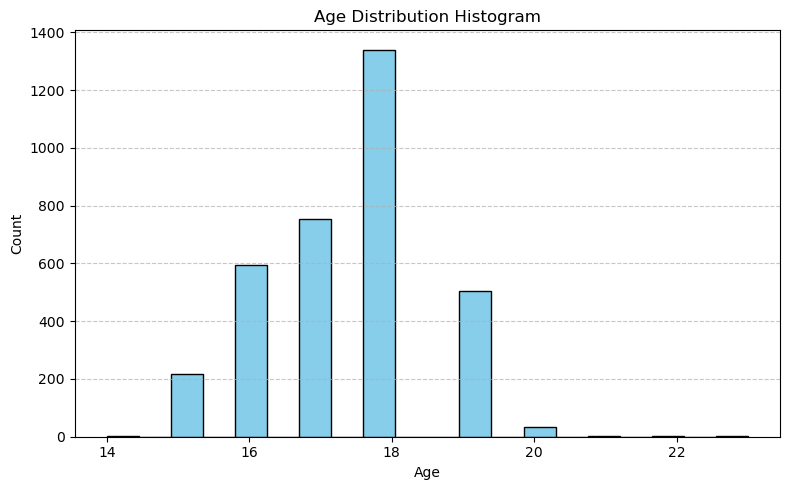

In [69]:
import matplotlib.pyplot as plt
# Filter out ages less than 5
df1_baseline_filtered = df1[df1['B2'] >= 5]

plt.figure(figsize=(8, 5))
plt.hist(df1_baseline_filtered['B2'].dropna(), bins=20, color='skyblue', edgecolor='black')

plt.title("Age Distribution Histogram")
plt.xlabel("Age")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

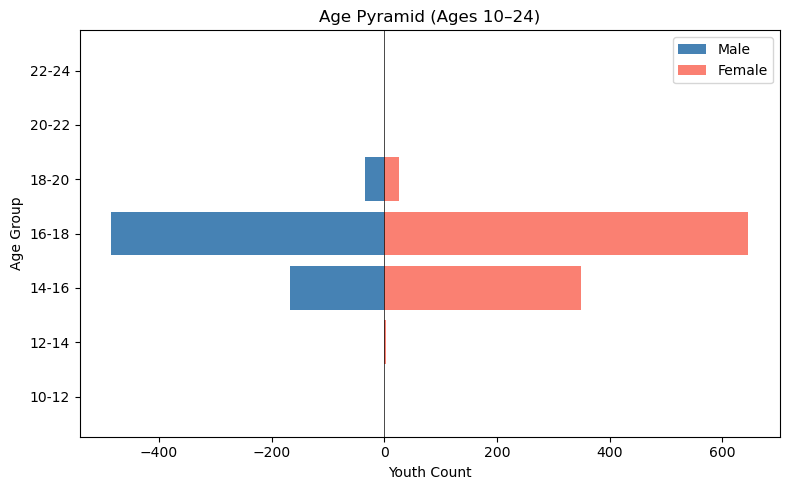

In [70]:
# Age pyramidal by gender

# Step 1: Recode gender and exclude unknowns
gender_map = {1: 'Female', 2: 'Male'}
df1_baseline = df1_baseline[df1_baseline['B3'].isin([1, 2])]  # Exclude unknown gender (4)
df1_baseline['B3'] = df1_baseline['B3'].map(gender_map)

# Step 2: Exclude ages below 10
df1_baseline = df1_baseline[df1_baseline['B2'] >= 10]

# Step 3: Define age bins for ages 10 to 24

age_bins = [10, 12, 14, 16, 18, 20, 22, 24]
age_labels = [f"{age_bins[i]}-{age_bins[i+1]}" for i in range(len(age_bins)-1)]
df1_baseline['age_group'] = pd.cut(df1_baseline['B2'], bins=age_bins, labels=age_labels, right=True)

# Step 4: Group by age group and gender
pyramid = df1_baseline.groupby(['age_group', 'B3']).size().unstack(fill_value=0)

# Step 5: Invert male values for pyramid
pyramid['Male'] = -pyramid.get('Male', 0)

# Step 6: Plot
fig, ax = plt.subplots(figsize=(8, 5))

# Bars
ax.barh(pyramid.index, pyramid['Male'], color='steelblue', label='Male')
ax.barh(pyramid.index, pyramid['Female'], color='salmon', label='Female')

# Formatting
ax.set_xlabel("Youth Count")
ax.set_ylabel("Age Group")
ax.set_title("Age Pyramid (Ages 10–24)")
ax.legend()
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 📈 4. Transformed outcomes data analysis

#### Percentage and number of  youth  at baseline and follow  who graduated or not from the education system

In [73]:
# Create a  cross table for number
table_num = pd.crosstab(df1['type'], df1['C0'])

print(table_num)

C0          No   Yes
type                
baseline  1728    10
follow     600  1146


In [74]:
# Create a table with percentage
table_perc = pd.crosstab(df1['type'], df1['C0'], normalize = 'index')* 100

print(table_perc)

C0               No        Yes
type                          
baseline  99.424626   0.575374
follow    34.364261  65.635739


#### Percentage of youth at follow who graduated from the education system by gender
(1=female    2 = Male     4 = no answer)

In [76]:
gender_system_follow  = pd.crosstab(df1_follow['B3'], df1_follow['C0'], normalize='index')* 100  # row-wise
gender_system_follow

C0,No,Yes
B3,,
1,37.917861,62.082139
2,28.939828,71.060172
4,100.000000,0.000000


### 4.1 Outcome employment analysis 1: Employment rate and Total transformed rate (All)

To calculate these rates, we first create three new columns:

* Graduated and employed: Youth who graduated from the education system (Yes from C0) and are employed (Yes from C00.1). The value will be “Yes”; otherwise, “No.”

* Graduated and self-employed: Youth who graduated from the education system (Yes from C0) and are self-employed (Yes from C00.2). The value will be “Yes”; otherwise, “No.”

* Not graduated but employed or self-employed: Youth who did not graduate from the education system (No from C0) and are either employed (Yes from C00.1) or self-employed (Yes from C00.2). The value will be “Yes”; otherwise, “No.”

* Graduate and in higher education: Youth who graduated from education system (C0 = Yes) and continue in higher education (C00.3 = Yes)

Using these three newly created columns, along with C00.3 (in higher education) and C00.4 (looking for a job), we then generate a summary table for both the baseline and follow-up surveys.

In [78]:
# Create a column in the dataset where youth IS graduated from educatin system AND employed 
df1['graduated_emp'] = np.where((df1['C0'] == 'Yes') & (df1['C00.1'] == 'Yes'), 'Yes', 'No')

In [79]:
# Create a column where in the dataset youth graduated from educatin system AND  self employed 
df1['graduated_self_emp'] = np.where((df1['C0'] == 'Yes') & (df1['C00.2'] == 'Yes'), 'Yes', 'No')

In [80]:
# Create a column where youth is  NOT graduated from educatin system AND has either a job or self employed 
df1['no_graduated_emp_or_selfEmp'] = np.where(
    (df1['C0'] == 'No') & ((df1['C00.1'] == 'Yes') | (df1['C00.2'] == 'Yes')),
    'Yes',
    'No'
)

In [81]:
# Create a column in the dataset where youth IS graduated from educatin system AND is in higher education
df1['graduated_H_edu'] = np.where((df1['C0'] == 'Yes') & (df1['C00.3'] == 'Yes'), 'Yes', 'No')

In [82]:
# Quick check 
df1[['type','C0', 'C00.1','graduated_emp', 'C00.2','graduated_self_emp', 'no_graduated_emp_or_selfEmp','C00.3','C00.4','C00.5','graduated_H_edu']].head()

,type,C0,C00.1,graduated_emp,C00.2,graduated_self_emp,no_graduated_emp_or_selfEmp,C00.3,C00.4,C00.5,graduated_H_edu
0,baseline,No,No,No,No,No,No,Yes,No,No,No
1,baseline,No,No,No,No,No,No,Yes,No,No,No
2,baseline,No,No,No,No,No,No,Yes,Yes,No,No
3,baseline,No,Yes,No,No,No,Yes,Yes,No,No,No
4,baseline,No,No,No,No,No,No,Yes,No,No,No


The code bellow  generates two summary tables (baseline & follow-up).Each table shows the __count of “Yes” and “No” for each key  variable__ related to:  Employed (C00.1 ), graduated from school & employed (graduated_emp), self employed C00.2(C00.2),  graduated and self employed (graduated_self_emp ), not graduated but either employed or self employed (no_graduated_emp_or_selfEmp), in higher education (C00.3), looking for job (C00.4) , Not studying or not working or not looking for job (C00.5 ), graduated and in higher education (graduated_H_edu).

In [84]:
cols = ['C00.1', 'graduated_emp', 'C00.2',
        'graduated_self_emp', 'no_graduated_emp_or_selfEmp','C00.3','C00.4','C00.5','graduated_H_edu']

for t in ['baseline', 'follow']:
    subset = df1[df1['type'] == t]
    summary = subset[cols].apply(lambda x: x.value_counts()).fillna(0).astype(int)
    print(f"\nSummary for {t.capitalize()}:")
    print(summary.T)   



Summary for Baseline:
                               No   Yes
C00.1                        1652    86
graduated_emp                1738     0
C00.2                        1687    51
graduated_self_emp           1738     0
no_graduated_emp_or_selfEmp  1611   127
C00.3                          36  1702
C00.4                        1576   162
C00.5                        1724    14
graduated_H_edu              1731     7

Summary for Follow:
                               No  Yes
C00.1                        1278  468
graduated_emp                1295  451
C00.2                        1690   56
graduated_self_emp           1697   49
no_graduated_emp_or_selfEmp  1723   23
C00.3                         896  850
C00.4                        1309  437
C00.5                        1705   41
graduated_H_edu              1463  283


Employment rate and the total transformed rate is calculated using the formula below.


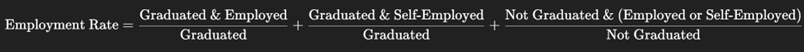


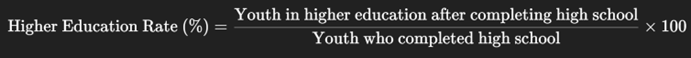


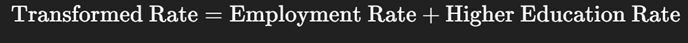

We could calculate these rates manually using the counts from the tables above; however, to automate the process, we’ll create variables to store those counts. While creating these variables, we should obtain the same value counts as those shown in the tables above. We will direclty  use them in the rate formulas for both the baseline and follow-up datasets.

__BASELINE__

In [87]:
# Filtering the merged dataset by baseline record
df1_baseline = df1[df1["type"] == "baseline"]

In [88]:
# variable holding count of youth graduated
graduated_baseline = (df1_baseline["C0"] == "Yes").sum()
graduated_baseline

10

In [89]:
# variable holding count of youth not graduated
Not_graduated_baseline = (df1_baseline["C0"] == "No").sum()
Not_graduated_baseline

1728

In [90]:
# variable holding count of youth graduated and employed
graduated_emp_baseline =(
    (df1_baseline["C0"] == "Yes") &
    (df1_baseline ["C00.1"] == "Yes")
).sum()

graduated_emp_baseline

0

In [91]:
# variable holding count of youth graduated and  self employed
graduated_self_emp_baseline =(
    (df1_baseline["C0"] == "Yes") &
    (df1_baseline ["C00.2"] == "Yes")
).sum()
graduated_self_emp_baseline

0

In [92]:
# Variable holding count of youth not graduate but either employed or self employed
no_graduated_emp_or_selfEmp_baseline = (
    (df1_baseline["C0"] == "No") &
    (
        (df1_baseline["C00.1"] == "Yes") |
        (df1_baseline["C00.2"] == "Yes")
    )
).sum()

no_graduated_emp_or_selfEmp_baseline    

127

In [93]:
# Variable holding count of graduated and in higher education (graduated_H_edu)

graduated_H_edu=(
    (df1_baseline["C0"] == "Yes") &
    (df1_baseline ["C00.3"] == "Yes")
).sum()

graduated_H_edu

7

In [94]:
# % youth graduated & employed at baseline 
percent_graduated_emp_base = (graduated_emp_baseline / graduated_baseline) *100
percent_graduated_emp_base

0.0

In [95]:
# % youth graduated & self employed at baseline 
percent_graduated_self_emp_base = (graduated_self_emp_baseline / graduated_baseline) *100
percent_graduated_self_emp_base

0.0

In [96]:
# % youth not graduated but either employed or  self employed at baseline 
percent_no_graduated_emp_or_selfEmp_base = (no_graduated_emp_or_selfEmp_baseline / Not_graduated_baseline)*100
percent_no_graduated_emp_or_selfEmp_base


7.349537037037036

In [97]:
# Employment rate at baseline
rate_employ_baseline = percent_graduated_emp_base + percent_graduated_self_emp_base + percent_no_graduated_emp_or_selfEmp_base
rate_employ_baseline

7.349537037037036

In [98]:
#  Rate of youth in higher education after graduation at baseline
higher_edu_baseline = (graduated_H_edu / graduated_baseline) *100
higher_edu_baseline

70.0

__Note__:  The number of youth graduated at baseline is very small but out of the 10 youth who had already graduated from the school system at baseline, 7 were enrolled in higher education.

__FOLLOW UP SURVEY__

In [101]:
# Filtering the merged dataset by follow up survey records
df1_follow = df1[df1["type"] == "follow"]

In [102]:
# variable holding count of youth graduated
graduated_follow = (df1_follow["C0"] == "Yes").sum()
graduated_follow

1146

In [103]:
# variable holding count of youth not graduated
Not_graduated_follow = (df1_follow["C0"] == "No").sum()
Not_graduated_follow

600

In [104]:
# variable holding count of youth graduated and employed
graduated_emp_follow =(
    (df1_follow["C0"] == "Yes") &
    (df1_follow ["C00.1"] == "Yes")
).sum()

graduated_emp_follow

451

In [105]:
# variable holding count of youth graduated and  self employed
graduated_self_emp_follow =(
    (df1_follow["C0"] == "Yes") &
    (df1_follow ["C00.2"] == "Yes")
).sum()
graduated_self_emp_follow

49

In [106]:
# Variable holding count of youth not graduate but either employed or self employed
no_graduated_emp_or_selfEmp_follow = (
    (df1_follow["C0"] == "No") &
    (
        (df1_follow["C00.1"] == "Yes") |
        (df1_follow["C00.2"] == "Yes")
    )
).sum()

no_graduated_emp_or_selfEmp_follow

23

In [107]:
# Variable holding count of graduated and in higher education (graduated_H_edu)

graduated_H_edu_follow=(
    (df1_follow["C0"] == "Yes") &
    (df1_follow ["C00.3"] == "Yes")
).sum()

graduated_H_edu_follow

283

In [108]:
# % youth graduated & employed at follow up  
percent_graduated_emp_follow = (graduated_emp_follow / graduated_follow) *100
percent_graduated_emp_follow

39.354275741710296

In [109]:
# % youth graduated & self employed at follow up
percent_graduated_self_emp_follow = (graduated_self_emp_follow / graduated_follow) *100
percent_graduated_self_emp_follow

4.275741710296685

In [110]:
# % youth not graduated but either employed or  self employed at follow up 
percent_no_graduated_emp_or_selfEmp_follow = (no_graduated_emp_or_selfEmp_follow / Not_graduated_follow)*100
percent_no_graduated_emp_or_selfEmp_follow


3.833333333333333

In [111]:
# Employment rate at follow up
rate_employ_follow = percent_graduated_emp_follow + percent_graduated_self_emp_follow + percent_no_graduated_emp_or_selfEmp_follow
rate_employ_follow

47.46335078534032

In [112]:
#  Rate of youth in higher education after graduation at follow 
higher_edu_follow = (graduated_H_edu_follow / graduated_follow) *100
higher_edu_follow


24.694589877835952

__Note__:  The number of youth graduated at follow is 1146  and out these 283 continued to higher education.

In [114]:
#  Transformed rate  at follow 
transformed_rate_follow = rate_employ_follow + higher_edu_follow
transformed_rate_follow

72.15794066317628

### 4.2 Outcome employment analysis 1: Employment rate and Total transformed rate (Gender)

#### 4.2.1 Employment rate and Total transformed rate for Male

__AT BASELINE__

In [118]:
# Filtering the merged dataset by male records
df1_male = df1[df1["B3"] == 2]

In [119]:

cols = ['C00.1', 'graduated_emp', 'C00.2',
        'graduated_self_emp', 'no_graduated_emp_or_selfEmp','C00.3','C00.4','C00.5','graduated_H_edu']

for t in ['baseline', 'follow']:
    subset = df1_male[df1_male['type'] == t]
    summary = subset[cols].apply(lambda x: x.value_counts()).fillna(0).astype(int)
    print(f"\nSummary for {t.capitalize()}:")
    print(summary.T)   



Summary for Baseline:
                              No  Yes
C00.1                        656   43
graduated_emp                699    0
C00.2                        678   21
graduated_self_emp           699    0
no_graduated_emp_or_selfEmp  641   58
C00.3                         25  674
C00.4                        627   72
C00.5                        691    8
graduated_H_edu              695    4

Summary for Follow:
                              No  Yes
C00.1                        470  228
graduated_emp                480  218
C00.2                        674   24
graduated_self_emp           679   19
no_graduated_emp_or_selfEmp  684   14
C00.3                        387  311
C00.4                        528  170
C00.5                        678   20
graduated_H_edu              573  125


In [120]:
# Filtering the merged dataset by male records and for baseline
df1_baseline_male = df1[(df1["B3"] == 2) & (df1["type"] == "baseline")]

In [121]:
# variable holding count of youth male graduated at baseline 
graduated_baseline_male = (df1_baseline_male["C0"] == "Yes").sum()
graduated_baseline_male

6

In [122]:
# variable holding count of male youth not graduated at baseline 
Not_graduated_baseline_male = (df1_baseline_male["C0"] == "No").sum()
Not_graduated_baseline_male

693

In [123]:
# variable holding count of male youth graduated and employed at baseline 
graduated_emp_baseline_male =(
    (df1_baseline_male["C0"] == "Yes") &
    (df1_baseline_male ["C00.1"] == "Yes")
).sum()

graduated_emp_baseline_male

0

In [124]:
# variable holding count of male youth graduated and  self employed at baseline 
graduated_self_emp_baseline_male =(
    (df1_baseline_male["C0"] == "Yes") &
    (df1_baseline_male ["C00.2"] == "Yes")
).sum()
graduated_self_emp_baseline_male

0

In [125]:
# Variable holding count of male youth not graduate but either employed or self employed at baseline 
no_graduated_emp_or_selfEmp_baseline_male = (
    (df1_baseline_male["C0"] == "No") &
    (
        (df1_baseline_male["C00.1"] == "Yes") |
        (df1_baseline_male["C00.2"] == "Yes")
    )
).sum()

no_graduated_emp_or_selfEmp_baseline_male   

58

In [127]:
# Variable holding count of male graduated and in higher education (graduated_H_edu) at baseline 

graduated_H_edu_baseline_male=(
    (df1_baseline_male["C0"] == "Yes") &
    (df1_baseline_male ["C00.3"] == "Yes")
).sum()

graduated_H_edu_baseline_male

4

In [128]:
# % male youth graduated & employed at baseline 
percent_graduated_emp_base_male = (graduated_emp_baseline_male / graduated_baseline_male) *100
percent_graduated_emp_base_male

0.0

In [129]:
# % male youth graduated & self employed at baseline 
percent_graduated_self_emp_base_male = (graduated_self_emp_baseline_male / graduated_baseline_male) *100
percent_graduated_self_emp_base_male

0.0

In [130]:
# % male youth not graduated but either employed or self-employed at baseline
percent_no_graduated_emp_or_selfEmp_base_male = (
    no_graduated_emp_or_selfEmp_baseline_male 
    / Not_graduated_baseline_male
) * 100

percent_no_graduated_emp_or_selfEmp_base_male


8.369408369408369

In [131]:
# Employment rate at baseline for male
rate_employ_baseline_male = (
    percent_graduated_emp_base_male
    + percent_graduated_self_emp_base_male
    + percent_no_graduated_emp_or_selfEmp_base_male
)

rate_employ_baseline_male

8.369408369408369

In [132]:
#  Rate of male youth in higher education after graduation at baseline
higher_edu_baseline_male = (graduated_H_edu_baseline_male / graduated_baseline_male) *100
higher_edu_baseline_male

66.66666666666666

__Note__:  The number of male youth graduated at baseline is very small but out of the 6 youth who had already graduated from the school system at baseline, 4 were enrolled in higher education.

__AT FOLLOW UP SURVEY__

In [135]:
# Filtering the merged dataset by male  records and at follow up survey
df1_follow_male = df1[(df1["B3"] == 2) & (df1["type"] == "follow")]

In [136]:
# variable holding count of youth male graduated at follow
graduated_follow_male = (df1_follow_male["C0"] == "Yes").sum()
graduated_follow_male

496

In [137]:
# variable holding count of male youth not graduated at follow
Not_graduated_follow_male = (df1_follow_male["C0"] == "No").sum()
Not_graduated_follow_male

202

In [138]:
# variable holding count of male youth graduated and employed at follow
graduated_emp_follow_male =(
    (df1_follow_male["C0"] == "Yes") &
    (df1_follow_male ["C00.1"] == "Yes")
).sum()

graduated_emp_follow_male


218

In [139]:
# variable holding count of male youth graduated and  self employed at follow
graduated_self_emp_follow_male =(
    (df1_follow_male["C0"] == "Yes") &
    (df1_follow_male ["C00.2"] == "Yes")
).sum()
graduated_self_emp_follow_male

19

In [140]:
# Variable holding count of male youth not graduate but either employed or self employed at follow 
no_graduated_emp_or_selfEmp_follow_male = (
    (df1_follow_male["C0"] == "No") &
    (
        (df1_follow_male["C00.1"] == "Yes") |
        (df1_follow_male["C00.2"] == "Yes")
    )
).sum()

no_graduated_emp_or_selfEmp_follow_male   

14

In [141]:
# Variable holding count of male graduated and in higher education (graduated_H_edu) at follow 

graduated_H_edu_follow_male=(
    (df1_follow_male["C0"] == "Yes") &
    (df1_follow_male ["C00.3"] == "Yes")
).sum()

graduated_H_edu_follow_male

125

In [142]:
# % male youth graduated & employed at follow
percent_graduated_emp_follow_male = (graduated_emp_follow_male / graduated_follow_male) *100
percent_graduated_emp_follow_male

43.95161290322581

In [143]:
# % male youth graduated & self employed at follow 
percent_graduated_self_emp_follow_male = (graduated_self_emp_follow_male / graduated_follow_male) *100
percent_graduated_self_emp_follow_male

3.8306451612903225

In [144]:
# % male youth not graduated but either employed or self-employed at follow
percent_no_graduated_emp_or_selfEmp_follow_male = (
    no_graduated_emp_or_selfEmp_follow_male 
    / Not_graduated_follow_male
) * 100

percent_no_graduated_emp_or_selfEmp_follow_male

6.9306930693069315

In [145]:
# Employment rate at follow for male
rate_employ_follow_male = (
    percent_graduated_emp_follow_male
    + percent_graduated_self_emp_follow_male
    + percent_no_graduated_emp_or_selfEmp_follow_male
)

rate_employ_follow_male

54.71295113382306

In [146]:
#  Rate of male youth in higher education after graduation at follow
higher_edu_follow_male = (graduated_H_edu_follow_male / graduated_follow_male) *100
higher_edu_follow_male

25.201612903225808

In [147]:
#  Transformed rate  at follow for male
transformed_rate_follow_male = rate_employ_follow_male + higher_edu_follow_male
transformed_rate_follow_male

79.91456403704888

#### 4.2.2 Employment rate and Total transformed rate for Female

__BASELINE__

In [150]:
# Filtering the merged dataset by female records
df1_female = df1[df1["B3"] == 1]

In [151]:
cols = ['C00.1', 'graduated_emp', 'C00.2',
        'graduated_self_emp', 'no_graduated_emp_or_selfEmp','C00.3','C00.4','C00.5','graduated_H_edu']

for t in ['baseline', 'follow']:
    subset = df1_female[df1_female['type'] == t]
    summary = subset[cols].apply(lambda x: x.value_counts()).fillna(0).astype(int)
    print(f"\nSummary for {t.capitalize()}:")
    print(summary.T)   


Summary for Baseline:
                               No   Yes
C00.1                         992    43
graduated_emp                1035     0
C00.2                        1006    29
graduated_self_emp           1035     0
no_graduated_emp_or_selfEmp   967    68
C00.3                          11  1024
C00.4                         945    90
C00.5                        1029     6
graduated_H_edu              1032     3

Summary for Follow:
                               No  Yes
C00.1                         807  240
graduated_emp                 814  233
C00.2                        1015   32
graduated_self_emp           1017   30
no_graduated_emp_or_selfEmp  1038    9
C00.3                         509  538
C00.4                         780  267
C00.5                        1026   21
graduated_H_edu               889  158


In [152]:
# Filtering the merged dataset by female records and for baseline
df1_baseline_female = df1[(df1["B3"] == 1) & (df1["type"] == "baseline")]

In [153]:
# variable holding count of youth female graduated at baseline 
graduated_baseline_female = (df1_baseline_female["C0"] == "Yes").sum()
graduated_baseline_female

4

In [154]:
# variable holding count of female youth not graduated at baseline 
Not_graduated_baseline_female = (df1_baseline_female["C0"] == "No").sum()
Not_graduated_baseline_female

1031

In [155]:
# variable holding count of female youth graduated and employed at baseline 
graduated_emp_baseline_female =(
    (df1_baseline_female["C0"] == "Yes") &
    (df1_baseline_female ["C00.1"] == "Yes")
).sum()

graduated_emp_baseline_female

0

In [156]:
# variable holding count of female youth graduated and  self employed at baseline 
graduated_self_emp_baseline_female =(
    (df1_baseline_female["C0"] == "Yes") &
    (df1_baseline_female ["C00.2"] == "Yes")
).sum()
graduated_self_emp_baseline_female


0

In [157]:
# Variable holding count of female youth not graduate but either employed or self employed at baseline 
no_graduated_emp_or_selfEmp_baseline_female = (
    (df1_baseline_female["C0"] == "No") &
    (
        (df1_baseline_female["C00.1"] == "Yes") |
        (df1_baseline_female["C00.2"] == "Yes")
    )
).sum()

no_graduated_emp_or_selfEmp_baseline_female 

68

In [158]:
# Variable holding count of female graduated and in higher education (graduated_H_edu) at baseline 

graduated_H_edu_baseline_female=(
    (df1_baseline_female["C0"] == "Yes") &
    (df1_baseline_female ["C00.3"] == "Yes")
).sum()

graduated_H_edu_baseline_female

3

In [159]:
# % female youth graduated & employed at baseline 
percent_graduated_emp_base_female = (graduated_emp_baseline_female / graduated_baseline_female) *100
percent_graduated_emp_base_female

0.0

In [160]:
# % female youth graduated & self employed at baseline 
percent_graduated_self_emp_base_female = (graduated_self_emp_baseline_female / graduated_baseline_female) *100
percent_graduated_self_emp_base_female

0.0

In [161]:
# % female youth not graduated but either employed or self-employed at baseline
percent_no_graduated_emp_or_selfEmp_base_female = (
    no_graduated_emp_or_selfEmp_baseline_female 
    / Not_graduated_baseline_female
) * 100

percent_no_graduated_emp_or_selfEmp_base_female

6.595538312318137

In [162]:
# Employment rate at baseline for female
rate_employ_baseline_female = (
    percent_graduated_emp_base_female
    + percent_graduated_self_emp_base_female
    + percent_no_graduated_emp_or_selfEmp_base_female
)

rate_employ_baseline_female

6.595538312318137

In [163]:
#  Rate of female youth in higher education after graduation at baseline
higher_edu_baseline_female = (graduated_H_edu_baseline_female / graduated_baseline_female) *100
higher_edu_baseline_female

75.0

__Note__:  The number of female youth graduated at baseline is very small.Out of the 4 youth who had already graduated from the school system at baseline, 3 were already enrolled in higher education.

__FOLLOW UP SURVEY__

In [166]:
# Filtering the merged dataset by female  records and at follow up survey
df1_follow_female = df1[(df1["B3"] == 1) & (df1["type"] == "follow")]

In [167]:
# variable holding count of youth female graduated at follow
graduated_follow_female = (df1_follow_female["C0"] == "Yes").sum()
graduated_follow_female

650

In [168]:
# variable holding count of female youth not graduated at follow
Not_graduated_follow_female = (df1_follow_female["C0"] == "No").sum()
Not_graduated_follow_female

397

In [169]:
# variable holding count of female youth graduated and employed at follow
graduated_emp_follow_female =(
    (df1_follow_female["C0"] == "Yes") &
    (df1_follow_female ["C00.1"] == "Yes")
).sum()

graduated_emp_follow_female

233

In [170]:
# variable holding count of female youth graduated and  self employed at follow
graduated_self_emp_follow_female =(
    (df1_follow_female["C0"] == "Yes") &
    (df1_follow_female ["C00.2"] == "Yes")
).sum()
graduated_self_emp_follow_female

30

In [171]:
# Variable holding count of female youth not graduate but either employed or self employed at follow 
no_graduated_emp_or_selfEmp_follow_female = (
    (df1_follow_female["C0"] == "No") &
    (
        (df1_follow_female["C00.1"] == "Yes") |
        (df1_follow_female["C00.2"] == "Yes")
    )
).sum()

no_graduated_emp_or_selfEmp_follow_female  

9

In [172]:
# Variable holding count of female graduated and in higher education (graduated_H_edu) at follow 

graduated_H_edu_follow_female=(
    (df1_follow_female["C0"] == "Yes") &
    (df1_follow_female ["C00.3"] == "Yes")
).sum()

graduated_H_edu_follow_female

158

In [173]:
# % female youth graduated & employed at follow
percent_graduated_emp_follow_female = (graduated_emp_follow_female / graduated_follow_female) *100
percent_graduated_emp_follow_female

35.84615384615385

In [174]:
# % female youth graduated & self employed at follow 
percent_graduated_self_emp_follow_female = (graduated_self_emp_follow_female / graduated_follow_female) *100
percent_graduated_self_emp_follow_female

4.615384615384616

In [175]:
# % female youth not graduated but either employed or self-employed at follow
percent_no_graduated_emp_or_selfEmp_follow_female = (
    no_graduated_emp_or_selfEmp_follow_female 
    / Not_graduated_follow_female
) * 100

percent_no_graduated_emp_or_selfEmp_follow_female

2.2670025188916876

In [176]:
# Employment rate at follow for female
rate_employ_follow_female = (
    percent_graduated_emp_follow_female
    + percent_graduated_self_emp_follow_female
    + percent_no_graduated_emp_or_selfEmp_follow_female
)

rate_employ_follow_female

42.72854098043015

In [177]:
#  Rate of female youth in higher education after graduation at follow
higher_edu_follow_female = (graduated_H_edu_follow_female / graduated_follow_female) *100
higher_edu_follow_female

24.307692307692307

In [178]:
#  Transformed rate  at follow for female
transformed_rate_follow_female = rate_employ_follow_female + higher_edu_follow_female
transformed_rate_follow_female

67.03623328812245

#### 4.2.3 Test difference between gender at follow

We conducted a two-proportion z-test to determine whether the employment rates (by employment status) of male and female  differ significantly at follow up.

Null hypothesis (H₀): Male and female have the same employment status rate.

Alternative hypothesis (H₁): Male and female have different employment status rates.

The test produces two key statistics:

Z-statistic: Measures the standardized difference between the two sample proportions.

P-value: Indicates the probability of observing such a difference (or a more extreme one) if the true employment rates were equal.

If the p-value is less than 0.05, we reject the null hypothesis and conclude that the difference in employment status rates between male and female  at follow-up is statistically significant.

__Difference between gender for status :  graduated and get employed at follow__

In [181]:
from statsmodels.stats.proportion import proportions_ztest

#  providing the counts of employed individuals by sex at follow
count = [graduated_emp_follow_male, graduated_emp_follow_female]  

# providing Sample sizes (total graduated) by sex
nobs = [graduated_follow_male,graduated_follow_female ]   

# Perform two-proportion z-test
stat, pval = proportions_ztest(count, nobs)

# printing the results
print(f"Z-statistic: {stat:.3f}")
print(f"P-value: {pval:.3f}")


Z-statistic: 2.783
P-value: 0.005


__Difference between gender for status : graduated and self employed at follow__

In [183]:
from statsmodels.stats.proportion import proportions_ztest

#  providing the counts of employed individuals by sex at follow
count = [graduated_self_emp_follow_male, graduated_self_emp_follow_male]  

# providing Sample sizes (total graduated) by sex
nobs = [graduated_follow_male,graduated_follow_female ]   

# Perform two-proportion z-test
stat, pval = proportions_ztest(count, nobs)

# printing the results
print(f"Z-statistic: {stat:.3f}")
print(f"P-value: {pval:.3f}")

Z-statistic: 0.850
P-value: 0.395


#### 4.2.4  Sector of employment at follow up 

__FOR ALL__

The code in the next cell is filtering subset of the merged dataset (df1) and stores it in a new variable called graduated_employed_follow. The filter keeps only the rows where all three conditions are true:

df1['type'] == 'follow' → selects only records from the follow-up survey.

df1['C0'] == 'Yes' → keeps only youth who graduated from the education system.

df1['C00.1'] == 'Yes' → keeps only youth who are employed.

In short, this subset (graduated_employed_follow) contains only youth who graduated and are employed at the follow-up survey round.

In [186]:
# Filtering the merged dataset for those who graduated and get employed and at  follow up survey
graduated_employed_follow = df1[(df1['type'] == 'follow') & (df1['C0'] == 'Yes') & (df1['C00.1'] == 'Yes')]

In [187]:
# displays the % distribution of sector of employment among youth who graduated and are employed at follow-up
graduated_employed_follow['C15'].value_counts(normalize=True).sort_values(ascending=False) * 100

17.0    47.893570
9.0     13.968958
3.0     12.416851
7.0      4.656319
13.0     4.434590
10.0     3.769401
8.0      2.660754
6.0      2.439024
11.0     2.217295
16.0     1.552106
15.0     1.108647
1.0      1.108647
4.0      0.665188
12.0     0.443459
14.0     0.443459
5.0      0.221729
Name: C15, dtype: float64

__MALE__

In [189]:
# Filtering the merged dataset for males who graduated and get employed and at  follow up survey
graduated_employed_follow_male = df1[(df1['type'] == 'follow') & (df1['C0'] == 'Yes') & (df1['C00.1'] == 'Yes') & (df1['B3'] == 2) ]

In [190]:
# displays the % distribution of sector of employment among male who graduated and are employed at follow-up
graduated_employed_follow_male['C15'].value_counts(normalize=True).sort_values(ascending=False) * 100

17.0    41.743119
9.0     13.761468
3.0     10.550459
7.0      7.798165
10.0     5.963303
8.0      4.587156
13.0     4.587156
6.0      3.669725
16.0     1.376147
11.0     1.376147
4.0      1.376147
15.0     0.917431
1.0      0.917431
14.0     0.917431
12.0     0.458716
Name: C15, dtype: float64

__FEMALE__

In [192]:
# Filtering the merged dataset for female who graduated and get employed and at follow up survey
graduated_employed_follow_female = df1[(df1['type'] == 'follow') & (df1['C0'] == 'Yes') & (df1['C00.1'] == 'Yes') & (df1['B3'] == 1) ]

In [193]:
# displays the % distribution of C15 among female who graduated and are employed at follow-up,sorted from most to least frequent
graduated_employed_follow_female['C15'].value_counts(normalize=True).sort_values(ascending=False) * 100

17.0    53.648069
3.0     14.163090
9.0     14.163090
13.0     4.291845
11.0     3.004292
10.0     1.716738
16.0     1.716738
7.0      1.716738
15.0     1.287554
1.0      1.287554
6.0      1.287554
8.0      0.858369
12.0     0.429185
5.0      0.429185
Name: C15, dtype: float64

#### 4.2.5 Income

__ALL__

In [196]:
# getting the informatin on data type for income column
df1['C19'].dtype

dtype('O')

The merged datase have also both 1 and 1.0 (and similarly for 2, 2.0, etc.), which suggests that C19 contains mixed data types (some integers and some floats). To clean that up, we need to convert all to integers. this is what the code in the nex cell is doing.

In [198]:
df1['C19'] = pd.to_numeric(df1['C19'], errors='coerce')

In [199]:
# checking value of C19 are in correct format after treatment 
df1['C19'].value_counts()

1.0    109
9.0     58
2.0     57
7.0     42
3.0     23
4.0     14
5.0      8
6.0      2
Name: C19, dtype: int64

In [200]:
# Creating a a cross table between range of income and round of survey
pd.crosstab(df1['C19'], df1['type'], normalize='columns') *100


type,baseline,follow
C19,,
1.0,49.640288,22.988506
2.0,5.035971,28.735632
3.0,1.438849,12.068966
4.0,2.877698,5.747126
5.0,3.597122,1.724138
6.0,0.000000,1.149425
7.0,20.863309,7.471264
9.0,16.546763,20.114943


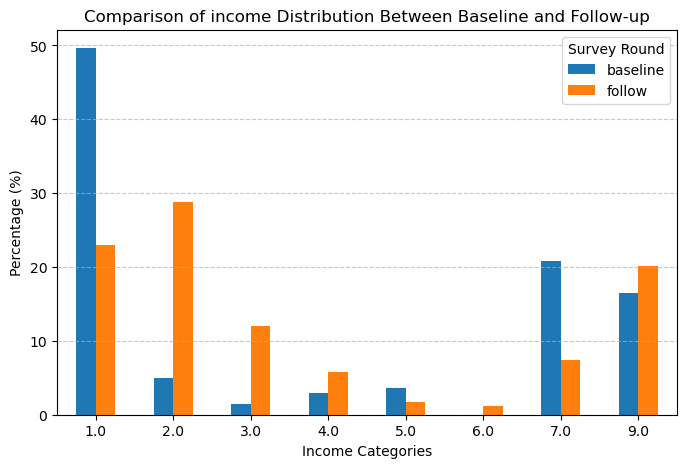

In [201]:
# Create the cross-tab (percentages)
c19_table = pd.crosstab(df1['C19'], df1['type'], normalize='columns') * 100

# Plot grouped bar chart
c19_table.plot(kind='bar', figsize=(8, 5))

# Customize chart
plt.title('Comparison of income Distribution Between Baseline and Follow-up')
plt.xlabel('Income Categories')
plt.ylabel('Percentage (%)')
plt.legend(title='Survey Round')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

__📊 Interpretation of the Chart__

1. Shift in income distribution between baseline and follow-up

* At baseline, the majority of participants were in the lowest income range (C19 = 1) — nearly 50% of respondents.

* At follow-up, that proportion dropped sharply to around 23%, suggesting fewer respondents remained in the lowest income group.

2. Increase in middle-income ranges

* The proportion of respondents in C19 = 2 and 3 (lower–middle income) rose substantially from about 5% → 29% (C19 = 2) and 1% → 12% (C19 = 3).

* This indicates a positive income shift among participants — more households moved into higher income brackets at follow-up.

3. Higher ranges (C19 = 4–7)

* The higher income categories show modest increases or stability, with C19 = 7 rising slightly.

* This further supports the view of overall upward income mobility.

4. Category 9 (no answer): The share of respondents who did not report income (C19 = 9) stayed roughly similar (around 16–20%), suggesting nonresponse bias remained consistent and likely doesn’t distort the trend.

The bar chart shows a notable improvement in income distribution between baseline and follow-up:Fewer people in the lowest income range. More people in the lower- and mid-income ranges.Stable or slightly growing higher-income representation.
In short, the data suggests positive economic progress among participants over the survey period.

__BY GENDER__

In [204]:
pd.crosstab(
    df1['C19'],
    [df1['type'], df1['B3']],
    normalize='columns'
) * 100

type   baseline                follow           
B3            1          2          1          2
C19                                             
1.0   48.571429  50.724638  21.875000  24.358974
2.0    1.428571   8.695652  33.333333  23.076923
3.0    1.428571   1.449275   8.333333  16.666667
4.0    2.857143   2.898551   3.125000   8.974359
5.0    4.285714   2.898551   2.083333   1.282051
6.0    0.000000   0.000000   1.041667   1.282051
7.0   21.428571  20.289855   4.166667  11.538462
9.0   20.000000  13.043478  26.041667  12.820513

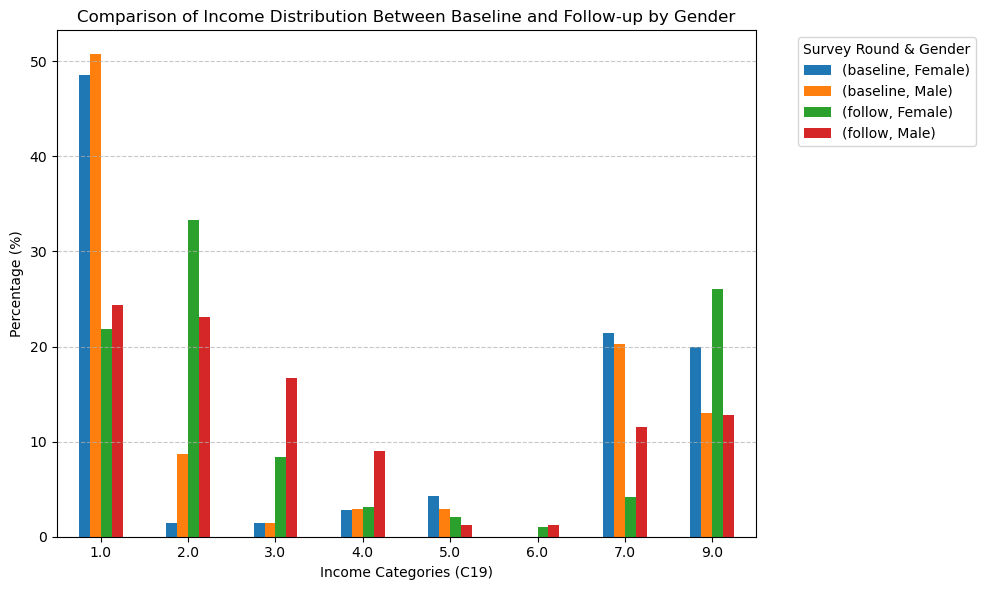

In [205]:

# Map gender codes to readable labels
df1['Gender'] = df1['B3'].map({1: 'Female', 2: 'Male'})

# Create a 3D cross-tab: C19 (income range) by type and gender
c19_table = pd.crosstab(
    df1['C19'],
    [df1['type'], df1['Gender']],
    normalize='columns'
) * 100

# Plot
c19_table.plot(kind='bar', figsize=(10, 6))

# Customize
plt.title('Comparison of Income Distribution Between Baseline and Follow-up by Gender')
plt.xlabel('Income Categories (C19)')
plt.ylabel('Percentage (%)')
plt.legend(title='Survey Round & Gender', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


📊 Interpretation of Income Distribution by Gender Across Rounds

1. Overall trend: upward income shift for both genders

* Both female and male respondents show a decline in the lowest income category (C19 = 1) from baseline to follow-up.

* This indicates an overall improvement in income status across the population, regardless of gender.

2. Stronger progress among females in mid-income categories

* At follow-up, female respondents show higher representation in C19 = 2 and C19 = 9, suggesting that more women moved from the lowest income range into middle-income brackets.

* The female distribution curve becomes more balanced, implying greater upward mobility compared to baseline.

3. Male distribution more spread across income levels

* Male respondents also improved, but their distribution at follow-up appears more dispersed, with noticeable shares in C19 = 2, 3, and 4, as well as in higher income brackets (C19 = 7–9).

* This indicates that while some males moved up economically, others still occupy lower or mid-range positions — showing a wider income spread.

4. Persistence of non-response (C19 = 9): The proportion of those who did not report income (C19 = 9) remains notable for both genders, slightly higher among females at follow-up. This could reflect either privacy concerns or informality of income sources, particularly among women.